# KCORC Summer School: TESPy Workshop
## Case Study: Double-stage R1233ZD(E) Heat Pump system -- for geothermal district heating supply

### Introduction

With the growing product range of large-scale heat pump systems, the use
of medium-deep geothermal energy has gained increasing attention over the
last years. E.g., the Energie-Wende-Garching (EWG) next to the TUM campus
has recently installed an ammonia heat pump (2 x 2.6 MW) to increase the
thermal capacity of the geothermal project.

In addition, more and more municipalities with rather low achievable
brine temperatures (e.g. 40 to 60 degC) consider using large-scale heat
pumps to upgrade the temperature level to the required district heating
supply temperatures (e.g. 90 degC). The figure below displays that the
utilization of such low- and medium-temperature resources significantly
increases the potential regions for geothermal applications. E.g. in the
northern areas of Munich.

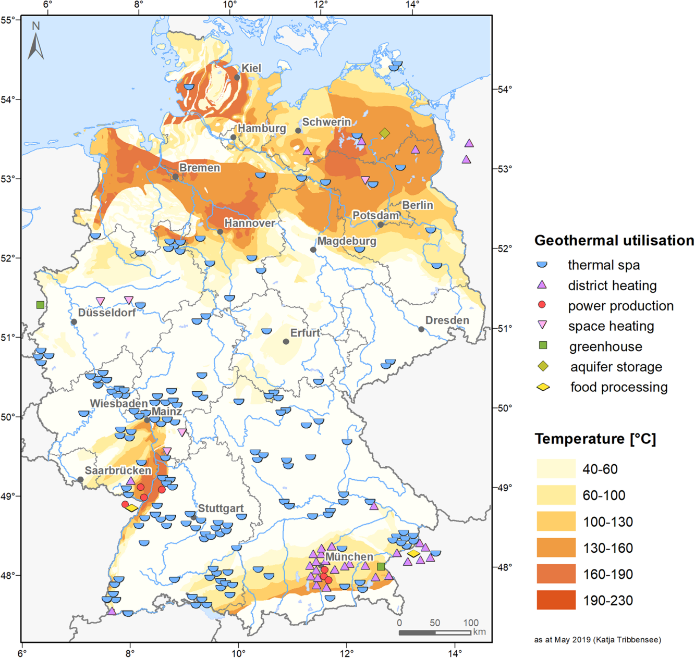

*Figure 1: Geothermal temperature distribution in Germany (taken from Moeck et al. 2020)*

Against this background, the case study investigates a potential
R1233ZD(E) case study for a typical medium deep project. Similar to a
feasibility study for a potential geothermal heat pump project in
Schwerin (cf. Mathes et al. 2022), this workshop exercise reconstructs
that problem as a two-loop R1233zd(E) heat pump system. As shown in
Figure 2, they are fully independent heat pumps that share the
geothermal and district-heating water streams in series.

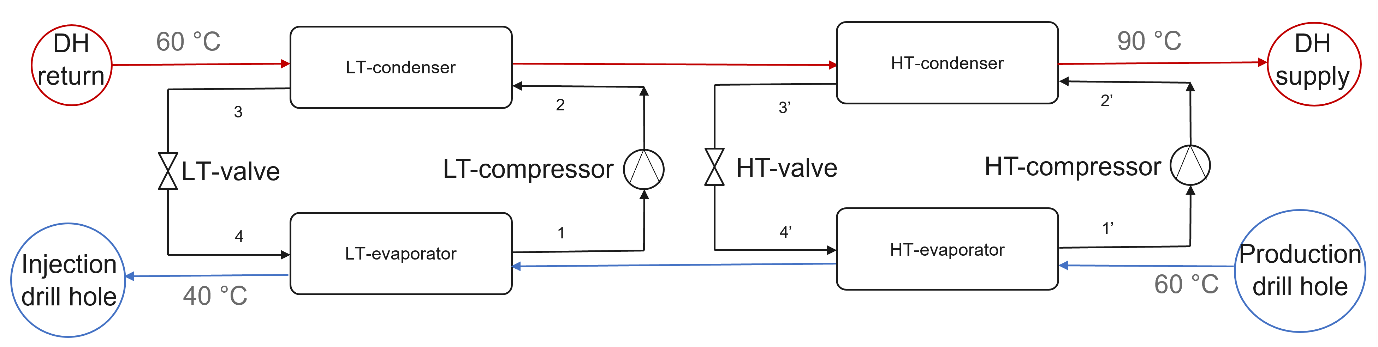

*Figure 2: Scheme of the proposed R1233ZD(E) heat pumps, with state points 1-4 (LT loop) and 1'-4' (HT loop)*

---

### This notebook

This notebook builds the **LT loop only** of a two-loop heat pump system.

```
geo intermediate (50 degC, from HT-evaporator) -> LT Evaporator -> geo injection (40 degC)

 1  -> LT compressor suction   (sat. vapour + superheat, low pressure)
 2  -> LT compressor discharge (superheated, high pressure)
 3  -> LT condenser outlet     (subcooled liquid, high pressure)
 4  -> LT expansion valve outlet -> LT evaporator inlet (low pressure, two-phase)
 1  -> closes the cycle at the LT evaporator outlet

DH return (60 degC, real) -> LT condenser (cold side) -> DH intermediate (75 degC, to HT-condenser)
```

The **LT loop is the one built here**, and it is the cooler of the two
(evaporates at 35 degC, condenses at 80 degC). It is responsible for the
**second (cooler) half of the geothermal glide**, 50 -> 40 degC, and sits
**first** in the district-heating line (receiving the real 60 degC return,
handing off an intermediate 75 degC to the HT loop). The HT loop is the
hotter of the two (evaporates at 45 degC, condenses at 95 degC), responsible
for the **first (warmer) half of the geothermal glide**, 60 -> 50 degC,
touching the real 60 degC production water directly and delivering the
real 90 degC supply target.

**Design point** (constant-efficiency compressor, `eta_s = 0.75`):

| | LT loop (this notebook) | HT loop (follow-up) |
|---|---|---|
| Evaporates at | 35 degC | 45 degC |
| Condenses at | 80 degC | 95 degC |
| Geothermal segment | 50 -> 40 degC | 60 -> 50 degC |
| Pressure ratio | approx 3.58 | approx 3.70 |


**What is fixed vs. a result in this notebook**: the geothermal side is now
**fully fixed**, inlet (50 degC), outlet (40 degC, the real injection
limit) and mass flow (100 kg/s) are all given directly, since the 50/40
split point is a genuine design choice (LT's own share of the geothermal
resource), not something left for the solver to find. On the
district heating side, both temperatures are fixed (60 degC real return,
75 degC placeholder outlet to the HT loop) but the **mass flow is left
free** and it becomes a result of the condenser's energy balance, once the
refrigerant mass flow is already known from the (fully-specified)
geothermal/evaporator side.

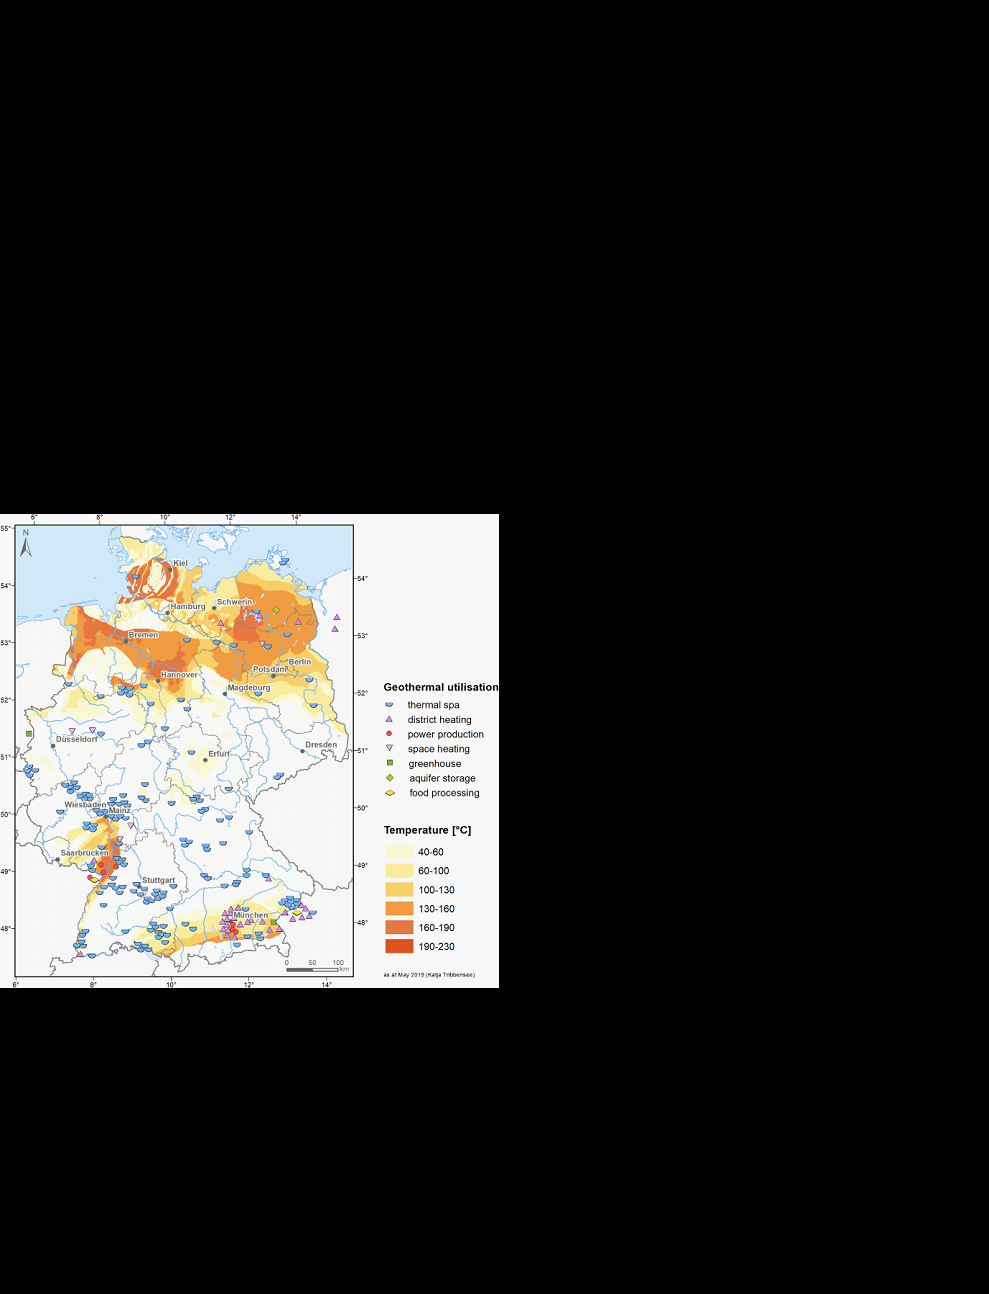
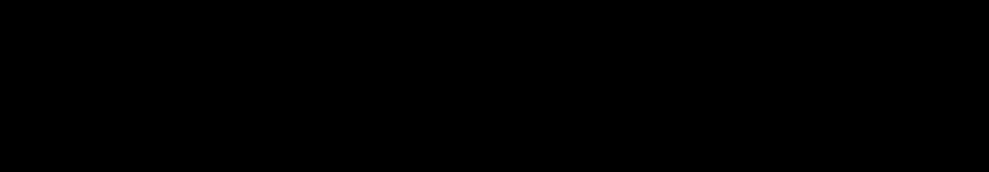
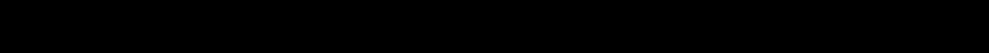
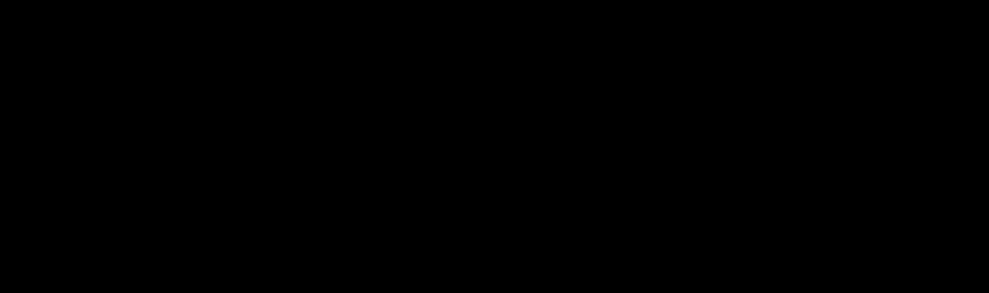
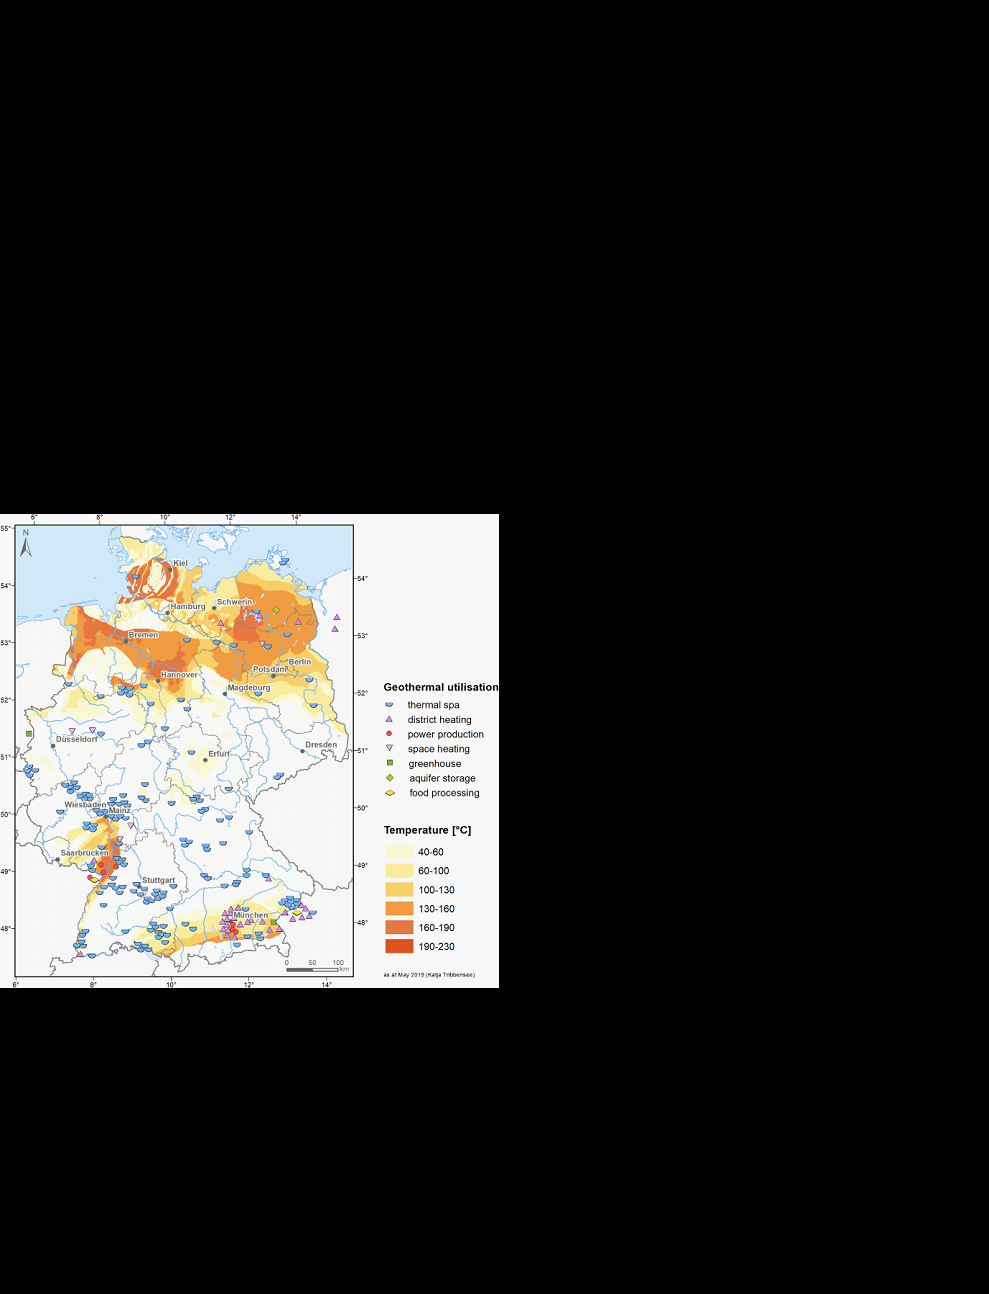

## Given:

**Table 1: Design Conditions**

| State point | Category | Parameter | LT loop (provided) | HT loop |
|---|---|---|---|---|
| - | Working fluid | Fluid | R1233ZD(E) | R1233ZD(E) |
| 4->1  /  4'->1' | Evaporator | Saturation temperature | 35 degC | 45 degC |
| 1  /  1' | | Superheat | 5 K | 5 K |
| 2->3  /  2'->3' | Condenser | Saturation temperature | 80 degC | 95 degC |
| 3  /  3' | | Subcooling | 3 K | 5 K |
| 1->2  /  1'->2' | Compressor | Isentropic efficiency | 0.75 (constant) | 0.75 (constant) |
| - | Working fluid flow | Mass flow rate | Calculated | Calculated |

**Table 2: Geothermal Heat Source & District Heating Sink at design**

| Parameter | Value |
|---|---|
| Geothermal fluid | Water |
| Geothermal inlet temperature | 60 degC |
| Geothermal outlet temperature | 40 degC |
| Geothermal mass flow rate | 100 kg/s |
| District heating return temperature | 60 degC |
| District heating supply temperature (design target) | 90 degC |
## Objective

Your task is to investigate the influence of low GWP zeotropic
working-fluid mixtures on the performance of the LT-ORC. Starting from
the validated TESPy model, replace R1233ZD(E) with selected zeotropic
mixtures and evaluate their thermodynamic performance under the same
geothermal operating conditions.

## Tasks

1. Review the design point model in the code below and run the simulation model to check the results.
2. Modify the TESPy model to replace the working fluid with one of the
   selected mixtures and investigate the performance of the cycle.
   Adjust boundary conditions if necessary.
3. Create the T-s diagram of the ORC system as well as the Q-T diagrams
   of the heat exchangers.
4. Extend the analysis to all mixture fractions available for the
   selected mixture. Ensure that each model converges while maintaining
   the same geothermal source conditions. Calculate the COP and the
   total UA of all heat exchangers. How do the values change with
   respect to the pure fluid baseline.
5. Replace the boundary conditions dimensioning the heat exchangers with
   fixed UA values from the pure fluid design simulation. How does the
   COP compare now?
6. Analyse the COP of the cycle for all given mixtures and mixture
   fractions. Compare the results with the reference R1233ZD(E) cycle
   and recommend the most suitable working fluid based on thermodynamic
   performance.
7. Change the working fluid in the HT-Heat Pump to a zeotropic mixture
   as well.


## 1. Imports

In [1]:
from tespy.networks import Network
from tespy.components import (
    Source, Sink, Compressor, Valve, SectionedHeatExchanger, CycleCloser
)
from tespy.connections import Connection

import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI


## 2. Network and units

In [2]:
nw = Network()
nw.units.set_defaults(
    temperature='degC', pressure='bar', pressure_difference='bar',
    enthalpy='kJ/kg', mass_flow='kg/s', power='kW', heat='kW'
)


## 3. Components

In [3]:
cc = CycleCloser('cycle closer')

compressor = Compressor('LT compressor (R1233zd(E))')
condenser = SectionedHeatExchanger('LT condenser')
valve = Valve('LT expansion valve')
evaporator = SectionedHeatExchanger('LT evaporator')

geo_source = Source('geothermal intermediate in')   # placeholder: from HT-evaporator (45 degC)
geo_sink = Sink('geothermal to injection')           # real: injection limit (30 degC)

dh_source = Source('district heating return')        # real: DH return (60 degC)
dh_sink = Sink('district heating intermediate out')   # placeholder: to HT-condenser (75 degC)


## 4. Connections -> working fluid loop (R1233zd(E))

In [4]:
c1 = Connection(cc, 'out1', compressor, 'in1', label='1')          # compressor suction
c2 = Connection(compressor, 'out1', condenser, 'in1', label='2')   # compressor discharge
c3 = Connection(condenser, 'out1', valve, 'in1', label='3')        # subcooled liquid
c4 = Connection(valve, 'out1', evaporator, 'in2', label='4')       # evaporator inlet
c1b = Connection(evaporator, 'out2', cc, 'in1', label='1b')        # closes the cycle at state 1

nw.add_conns(c1, c2, c3, c4, c1b)


## 5. Connections -> geothermal side (evaporator, hot side)

In [5]:
gC = Connection(geo_source, 'out1', evaporator, 'in1', label='geo-in')
gD = Connection(evaporator, 'out1', geo_sink, 'in1', label='geo-out')

nw.add_conns(gC, gD)


## 6. Connections -> district heating side (condenser, cold side)

In [6]:
d1 = Connection(dh_source, 'out1', condenser, 'in2', label='dh-in')
d2 = Connection(condenser, 'out2', dh_sink, 'in1', label='dh-out')

nw.add_conns(d1, d2)


## 7. Refrigerant-side design point (temperatures & pressures)


In [7]:
FLUID = 'R1233zd(E)'
T_evap = 35       # degC, saturation temperature in the evaporator (5 K below the 40 degC injection limit)
T_cond = 80       # degC, saturation temperature in the condenser
superheat = 5     # K, suction superheat (dry-compression margin)
subcool = 3        # K, liquid subcooling ahead of the expansion valve

p_evap = PropsSI('P', 'T', T_evap + 273.15, 'Q', 1, FLUID) / 1e5   # bar
p_cond = PropsSI('P', 'T', T_cond + 273.15, 'Q', 0, FLUID) / 1e5   # bar

print(f'p_evap = {p_evap:.3f} bar, p_cond = {p_cond:.3f} bar, pr = {p_cond / p_evap:.2f}')


p_evap = 1.837 bar, p_cond = 6.586 bar, pr = 3.58


## 8. Parameters -> geothermal side (evaporator)

The geothermal side is now **fully fixed**: inlet (50 degC), outlet
(40 degC, the real injection limit) and mass flow (100 kg/s) are all given
directly. The 50 degC inlet is LT's own share of the geothermal resource --
the geothermal glide splits 60 -> 50 degC for the HT loop and 50 -> 40 degC
for this LT loop, a design choice rather than something solved for.


In [8]:
evaporator.set_attr(pr1=1, pr2=1)   # no pressure drop assumed on either side

gC.set_attr(fluid={'water': 1}, T=50, p=5, m=100)   # LT's own geothermal segment: 50 -> 40 degC
gD.set_attr(T=40)                                   # real: injection limit


## 9. Parameters -> district heating side (condenser)

Both district heating temperatures are fixed (60 degC real return, 75 degC
placeholder outlet to the HT loop), but the **mass flow is left free**. It
becomes a result of the condenser's energy balance, evaluated once the
refrigerant mass flow is already known from the fully-specified geothermal
side (Section 8).


In [9]:
condenser.set_attr(pr1=1, pr2=1)   # no pressure drop assumed on either side

d1.set_attr(fluid={'water': 1}, T=60, p=5)   # real: district heating return -- mass flow left FREE (result)
d2.set_attr(T=75)                            # placeholder outlet (-> HT-condenser)


## 10. Compressor -> constant isentropic efficiency

`eta_s = 0.75` is used as a representative "real machine" figure covering
both internal compression losses and motor/drive/oil-pump losses.


In [10]:
compressor.set_attr(eta_s=0.75)

c1.set_attr(fluid={FLUID: 1}, p=p_evap, td_dew=superheat)   # mass flow left FREE (result)
c2.set_attr(p=p_cond)
c3.set_attr(td_bubble=subcool)


## 11. Solve

In [11]:
nw.solve('design')
nw.print_results()


 block   0 | scalar          | iterations:   2 | residual: 4.19e-17 | LT compressor (R1233zd(E)).eta_s
 block   1 | scalar          | iterations:   3 | residual: 4.55e-14 | LT evaporator.energy_balance_constraints
 block   2 | scalar          | iterations:   3 | residual: 0.00e+00 | LT condenser.energy_balance_constraints

##### RESULTS (Compressor) #####
+----------------------------+----------+----------+-----------+----------+
|                            |        P |       pr |        dp |    eta_s |
|----------------------------+----------+----------+-----------+----------|
| LT compressor (R1233zd(E)) | 9.86e+02 | 3.58e+00 | -4.75e+00 | 7.50e-01 |
+----------------------------+----------+----------+-----------+----------+
##### RESULTS (SectionedHeatExchanger) #####
+---------------+-----------+----------+----------+----------+----------+----------+----------+-----------+----------+----------+----------+----------+------------+----------+------------+----------+-----------+------

## 12. Pinch-point check

In [12]:
print('Refrigerant (R1233zd(E)) mass flow rate:', round(c1.m.val, 3), 'kg/s')
print('District-heating mass flow rate (RESULT):', round(d1.m.val, 2), 'kg/s')
print()
print(f"{'Component':<15}{'ttd_u [K]':>12}{'ttd_l [K]':>12}")
for hx in [evaporator, condenser]:
    flag_u = '  <-- violation!' if hx.ttd_u.val < 0 else ''
    flag_l = '  <-- violation!' if hx.ttd_l.val < 0 else ''
    print(f"{hx.label:<15}{hx.ttd_u.val:>12.2f}{hx.ttd_l.val:>12.2f}"
          f"{flag_u if hx.ttd_u.val < 0 else flag_l}")

if c2.x.val < 1:
    print()
    print(f'NOTE: compressor discharge quality x = {c2.x.val:.3f} (< 1) -- wet compression. '
          'Increase `superheat` in Section 7 and re-run from there.')
else:
    print()
    print(f'Discharge is dry (T={c2.T.val:.1f} degC vs. T_cond={T_cond} degC, '
          f'{c2.T.val - T_cond:.1f} K of superheat at the outlet).')


Refrigerant (R1233zd(E)) mass flow rate: 30.514 kg/s
District-heating mass flow rate (RESULT): 82.22 kg/s

Component         ttd_u [K]   ttd_l [K]
LT evaporator         10.00        5.00
LT condenser          12.10       17.00

Discharge is dry (T=87.1 degC vs. T_cond=80 degC, 7.1 K of superheat at the outlet).


## 13. Key results

In [13]:
P_comp = compressor.P.val
Q_evap = evaporator.Q.val
Q_cond = condenser.Q.val

Q_useful = -Q_cond   # kW, heat delivered to the district-heating intermediate stream
COP = Q_useful / P_comp
pr = c2.p.val / c1.p.val

print('================ LT LOOP SUMMARY ================')
print(f'Refrigerant                  : {FLUID}')
print(f'Refrigerant mass flow rate   : {c1.m.val:8.2f} kg/s')
print(f'Pressure ratio                : {pr:8.2f}')
print(f'Isentropic efficiency         : {compressor.eta_s.val * 100:8.2f} %')
print(f'Compressor discharge temp.    : {c2.T.val:8.1f} degC')
print(f'Compressor power              : {P_comp:8.1f} kW')
print(f'Evaporator duty               : {-Q_evap:8.1f} kW')
print(f'Condenser duty                : {Q_useful:8.1f} kW')
print(f'COP (LT loop only)            : {COP:8.2f}')


================ LT LOOP SUMMARY ================
Refrigerant                  : R1233zd(E)
Refrigerant mass flow rate   :    30.51 kg/s
Pressure ratio                :     3.58
Isentropic efficiency         :    75.00 %
Compressor discharge temp.    :     87.1 degC
Compressor power              :    985.6 kW
Evaporator duty               :   4179.3 kW
Condenser duty                :   5164.9 kW
COP (LT loop only)            :     5.24


## 14. T-s diagram and T-Q diagrams


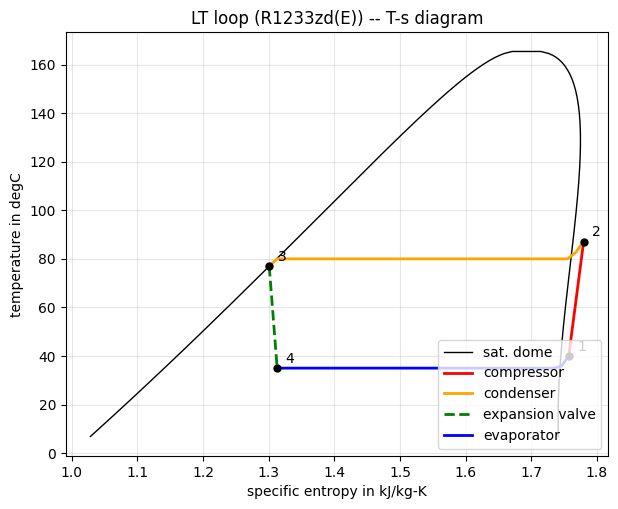

In [14]:
def conn_Ts(conn):
    p_Pa = conn.p.val * 1e5
    h_Jkg = conn.h.val * 1e3
    T = PropsSI('T', 'P', p_Pa, 'H', h_Jkg, FLUID) - 273.15
    s = PropsSI('S', 'P', p_Pa, 'H', h_Jkg, FLUID) / 1e3
    return T, s


def isobar_Ts(p_bar, h1_kJkg, h2_kJkg, n=40):
    p_Pa = p_bar * 1e5
    hs = np.linspace(h1_kJkg, h2_kJkg, n) * 1e3
    T = PropsSI('T', 'P', p_Pa, 'H', hs, FLUID) - 273.15
    s = PropsSI('S', 'P', p_Pa, 'H', hs, FLUID) / 1e3
    return T, s


T_crit = PropsSI('Tcrit', FLUID)
T_dome = np.linspace(280, T_crit - 0.3, 200)
sf = PropsSI('S', 'T', T_dome, 'Q', 0, FLUID) / 1e3
sg = PropsSI('S', 'T', T_dome, 'Q', 1, FLUID) / 1e3
T_dome_C = T_dome - 273.15

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(np.concatenate([sf, sg[::-1]]), np.concatenate([T_dome_C, T_dome_C[::-1]]),
        'k-', lw=1, label='sat. dome')

states = {'1': c1, '2': c2, '3': c3, '4': c4}
pts = {k: conn_Ts(v) for k, v in states.items()}

ax.plot([pts['1'][1], pts['2'][1]], [pts['1'][0], pts['2'][0]], 'r-', lw=2, label='compressor')
T23, s23 = isobar_Ts(c2.p.val, c2.h.val, c3.h.val)
ax.plot(s23, T23, 'orange', lw=2, label='condenser')
ax.plot([pts['3'][1], pts['4'][1]], [pts['3'][0], pts['4'][0]], 'g--', lw=2, label='expansion valve')
T41, s41 = isobar_Ts(c4.p.val, c4.h.val, c1.h.val)
ax.plot(s41, T41, 'b-', lw=2, label='evaporator')

for k, (T, s) in pts.items():
    ax.plot(s, T, 'ko', ms=5)
    ax.annotate(k, (s, T), textcoords='offset points', xytext=(6, 4))

ax.set_xlabel('specific entropy in kJ/kg-K')
ax.set_ylabel('temperature in degC')
ax.set_title('LT loop (R1233zd(E)) -- T-s diagram')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.show()


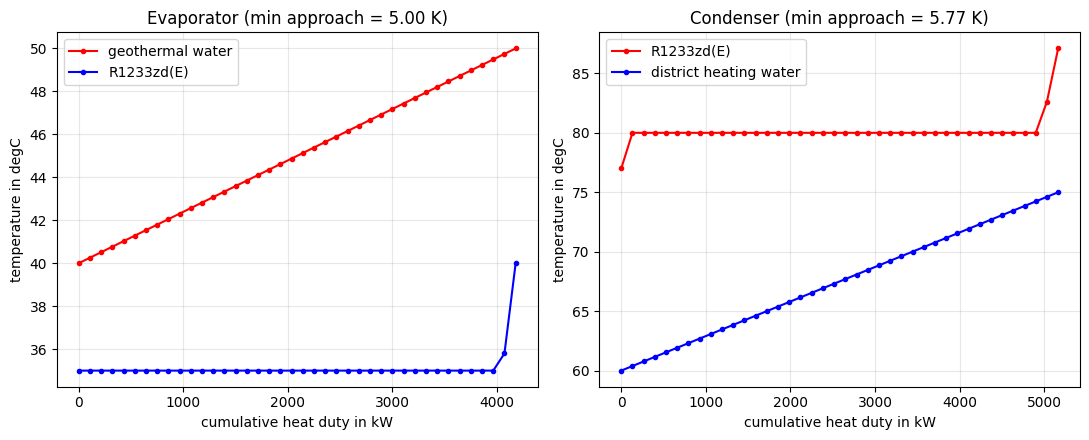

In [15]:
def counter_current_profile(m_hot, fluid_hot, p_hot_in_bar, p_hot_out_bar, h_hot_in, h_hot_out,
                             m_cold, fluid_cold, p_cold_in_bar, p_cold_out_bar, h_cold_in, h_cold_out,
                             n=40):
    Q_total = m_cold * (h_cold_out - h_cold_in)  # kW
    Q = np.linspace(0, Q_total, n)
    h_cold = h_cold_in + Q / m_cold
    h_hot = h_hot_out + Q / m_hot
    p_cold = np.linspace(p_cold_in_bar, p_cold_out_bar, n) * 1e5
    p_hot = np.linspace(p_hot_out_bar, p_hot_in_bar, n) * 1e5
    T_cold = PropsSI('T', 'P', p_cold, 'H', h_cold * 1e3, fluid_cold) - 273.15
    T_hot = PropsSI('T', 'P', p_hot, 'H', h_hot * 1e3, fluid_hot) - 273.15
    return Q, T_hot, T_cold


fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))

Q, Th, Tc = counter_current_profile(
    gC.m.val, 'water', gC.p.val, gD.p.val, gC.h.val, gD.h.val,
    c4.m.val, FLUID, c4.p.val, c1.p.val, c4.h.val, c1.h.val)
axs[0].plot(Q, Th, 'r-o', ms=3, label='geothermal water')
axs[0].plot(Q, Tc, 'b-o', ms=3, label=FLUID)
axs[0].set_title(f'Evaporator (min approach = {(Th - Tc).min():.2f} K)')
axs[0].set_xlabel('cumulative heat duty in kW')
axs[0].set_ylabel('temperature in degC')
axs[0].legend()
axs[0].grid(alpha=0.3)

Q, Th, Tc = counter_current_profile(
    c2.m.val, FLUID, c2.p.val, c3.p.val, c2.h.val, c3.h.val,
    d1.m.val, 'water', d1.p.val, d2.p.val, d1.h.val, d2.h.val)
axs[1].plot(Q, Th, 'r-o', ms=3, label=FLUID)
axs[1].plot(Q, Tc, 'b-o', ms=3, label='district heating water')
axs[1].set_title(f'Condenser (min approach = {(Th - Tc).min():.2f} K)')
axs[1].set_xlabel('cumulative heat duty in kW')
axs[1].set_ylabel('temperature in degC')
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
